# FSNet Winner Regions From Metrics

This notebook computes per-instance FSNet ensemble metrics and plots winner regions in a 2D metric space. It is intentionally self-contained and does not import `eval.py`.


In [1]:
import glob
import itertools
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset

from utils.evaluator import Evaluator
from utils.trainer import DEVICE, create_model, load_instance


## Config

In [2]:
RUN_DIR = 'results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260315-172824_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre'
OUT_PNG = 'results/fsnet_seed0_winner_regions_metrics.png'
SUBSET_N = 400
BATCH_SIZE = 128
MERIT_EQ_WEIGHT = 1e5
MERIT_INEQ_WEIGHT = 1e5
MIN_WINS_TO_PLOT = 10

# If True, automatically search a small set of metric pairs and use the best pair.
AUTO_SELECT_PAIR = True

# Used only when AUTO_SELECT_PAIR = False.
X_METRIC = 'disagreement_std'
Y_METRIC = 'winner_move_l2'

print('run_dir:', RUN_DIR)
print('out_png:', OUT_PNG)
print('subset_n:', SUBSET_N)
print('device:', DEVICE)


run_dir: results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260315-172824_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre
out_png: results/fsnet_seed0_winner_regions_metrics.png
subset_n: 400
device: cpu


## Helpers

In [3]:
def resolve_checkpoints(run_dir):
    pattern = os.path.join(run_dir, 'members', 'member_[0-9]*.pt')
    member_files = sorted(
        [
            f for f in glob.glob(pattern)
            if os.path.basename(f).startswith('member_') and '_epoch_' not in os.path.basename(f)
        ]
    )
    if member_files:
        return member_files
    model_pt = os.path.join(run_dir, 'model.pt')
    if os.path.isfile(model_pt):
        return [model_pt]
    raise FileNotFoundError(f'No model.pt or members/member_*.pt found in {run_dir}')


def load_single_model(ckpt_path, opt_problem):
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    config = ckpt['config']
    model = create_model(opt_problem, config['method'], config)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model, config


def evaluate_member(model, evaluator, dataset, batch_size=128):
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)
    out = {k: [] for k in ['raw_merit', 'final_merit', 'repair_gain', 'move_l2']}

    for x_batch, _ in loader:
        x_batch = x_batch.to(DEVICE)
        with torch.no_grad():
            y_raw = evaluator.opt_problem.scale(model(x_batch))
            y_final = evaluator._post_process_predictions(x_batch, y_raw)

            raw_merit = (
                evaluator.opt_problem.obj_fn(y_raw)
                + MERIT_EQ_WEIGHT * evaluator.opt_problem.eq_resid(x_batch, y_raw).abs().sum(dim=1)
                + MERIT_INEQ_WEIGHT * evaluator.opt_problem.ineq_resid(x_batch, y_raw).abs().sum(dim=1)
            )
            final_merit = (
                evaluator.opt_problem.obj_fn(y_final)
                + MERIT_EQ_WEIGHT * evaluator.opt_problem.eq_resid(x_batch, y_final).abs().sum(dim=1)
                + MERIT_INEQ_WEIGHT * evaluator.opt_problem.ineq_resid(x_batch, y_final).abs().sum(dim=1)
            )
            move_l2 = torch.linalg.norm(y_final - y_raw, dim=1)
            repair_gain = raw_merit - final_merit

        for k, v in {
            'raw_merit': raw_merit,
            'final_merit': final_merit,
            'repair_gain': repair_gain,
            'move_l2': move_l2,
        }.items():
            out[k].append(v.detach().cpu().numpy())

    return {k: np.concatenate(v) for k, v in out.items()}


def score_pair(x, y):
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.3, random_state=0, stratify=y
    )
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=ConvergenceWarning)
        warnings.simplefilter('ignore', category=UserWarning)
        clf = QuadraticDiscriminantAnalysis(reg_param=1e-3)
        clf.fit(x_train, y_train)
        pred = clf.predict(x_test)
    return balanced_accuracy_score(y_test, pred)


## Load Ensemble And Compute Per-Instance Metrics

In [4]:
ckpts = resolve_checkpoints(RUN_DIR)
first = torch.load(ckpts[0], map_location='cpu', weights_only=False)
cfg = dict(first['config'])
cfg['ensemble_post'] = 'post'
cfg['ensemble_agg'] = 'best_merit'
cfg['_eval_only'] = True

problem, _ = load_instance(cfg)
evaluator = Evaluator(problem, 'FSNet', cfg)
x_test, y_test = problem.test_dataset.tensors
subset = TensorDataset(x_test[:SUBSET_N], y_test[:SUBSET_N])

member_out = []
for i, ckpt in enumerate(ckpts):
    print(f'evaluating member {i}...')
    model, _ = load_single_model(ckpt, problem)
    member_out.append(evaluate_member(model, evaluator, subset, batch_size=BATCH_SIZE))

arrays = {k: np.stack([m[k] for m in member_out], axis=0) for k in member_out[0].keys()}
winner = arrays['final_merit'].argmin(axis=0)
winner_counts = np.bincount(winner, minlength=arrays['final_merit'].shape[0])
active_members = np.where(winner_counts >= MIN_WINS_TO_PLOT)[0]
plot_mask = np.isin(winner, active_members)

raw_sorted = np.sort(arrays['raw_merit'], axis=0)
final_sorted = np.sort(arrays['final_merit'], axis=0)

metrics = {
    'disagreement_std': arrays['final_merit'].std(axis=0),
    'raw_disagree_std': arrays['raw_merit'].std(axis=0),
    'move_std': arrays['move_l2'].std(axis=0),
    'repair_gain_std': arrays['repair_gain'].std(axis=0),
    'winner_move_l2': arrays['move_l2'][winner, np.arange(len(winner))],
    'winner_repair_gain': arrays['repair_gain'][winner, np.arange(len(winner))],
    'raw_margin': raw_sorted[1] - raw_sorted[0],
    'final_margin': final_sorted[1] - final_sorted[0],
}

print('winner counts:', winner_counts.tolist())
print('active members:', active_members.tolist())
print('points kept:', int(plot_mask.sum()))
if len(active_members) < 2:
    raise RuntimeError('Fewer than 2 members meet MIN_WINS_TO_PLOT. Increase SUBSET_N or lower MIN_WINS_TO_PLOT.')


evaluating member 0...
evaluating member 1...
evaluating member 2...
evaluating member 3...
evaluating member 4...
winner counts: [196, 95, 1, 40, 68]
active members: [0, 1, 3, 4]
points kept: 399


## Pick A 2D Metric Pair

In [5]:
labels = winner[plot_mask]

if AUTO_SELECT_PAIR:
    best = None
    for f1, f2 in itertools.combinations(metrics.keys(), 2):
        x = np.column_stack([metrics[f1][plot_mask], metrics[f2][plot_mask]])
        try:
            score = score_pair(x, labels)
        except Exception:
            continue
        if best is None or score > best[0]:
            best = (score, f1, f2)

    if best is None:
        raise RuntimeError('Could not score any metric pair.')

    BEST_SCORE, X_METRIC, Y_METRIC = best
else:
    BEST_SCORE = None

print('x_metric:', X_METRIC)
print('y_metric:', Y_METRIC)
if BEST_SCORE is not None:
    print('balanced_accuracy:', round(float(BEST_SCORE), 4))


x_metric: raw_disagree_std
y_metric: winner_repair_gain
balanced_accuracy: 0.3543


## Plot Winner Regions

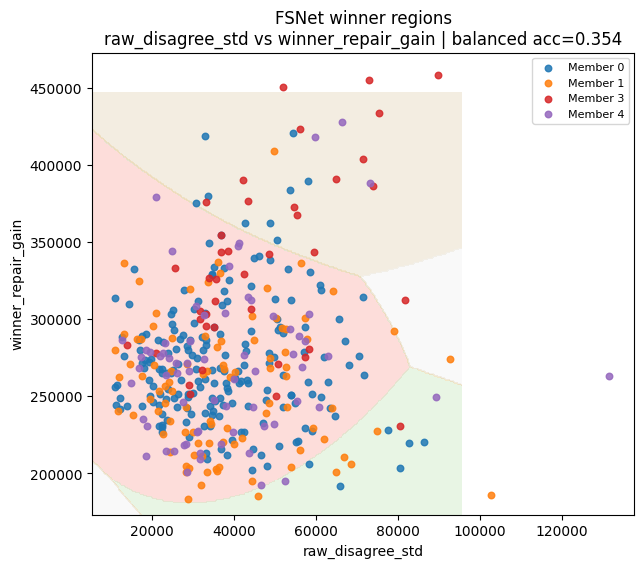

saved_plot: results/fsnet_seed0_winner_regions_metrics.png


In [6]:
x = metrics[X_METRIC][plot_mask]
y = metrics[Y_METRIC][plot_mask]
plot_xy = np.column_stack([x, y])

with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    warnings.simplefilter('ignore', category=UserWarning)
    clf = QuadraticDiscriminantAnalysis(reg_param=1e-3)
    clf.fit(plot_xy, labels)

x1_min, x1_max = np.quantile(x, [0.01, 0.99])
x2_min, x2_max = np.quantile(y, [0.01, 0.99])
pad1 = 0.08 * max(x1_max - x1_min, 1e-9)
pad2 = 0.08 * max(x2_max - x2_min, 1e-9)

gx, gy = np.meshgrid(
    np.linspace(x1_min - pad1, x1_max + pad1, 300),
    np.linspace(x2_min - pad2, x2_max + pad2, 300),
)
grid = np.column_stack([gx.ravel(), gy.ravel()])
gz = clf.predict(grid).reshape(gx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
levels = np.arange(gz.max() + 2) - 0.5
ax.contourf(gx, gy, gz, levels=levels, cmap='Pastel1', alpha=0.45)

cmap = plt.get_cmap('tab10')
for m in active_members:
    mm = labels == m
    if not np.any(mm):
        continue
    ax.scatter(x[mm], y[mm], s=22, alpha=0.85, color=cmap(m), label=f'Member {m}')

title = f'FSNet winner regions\n{X_METRIC} vs {Y_METRIC}'
if BEST_SCORE is not None:
    title += f' | balanced acc={BEST_SCORE:.3f}'
ax.set_title(title)
ax.set_xlabel(X_METRIC)
ax.set_ylabel(Y_METRIC)
ax.legend(fontsize=8)

os.makedirs(os.path.dirname(OUT_PNG), exist_ok=True)
fig.savefig(OUT_PNG, dpi=180, bbox_inches='tight')
plt.show()
print('saved_plot:', OUT_PNG)
